<a href="https://colab.research.google.com/github/ShreyaGautamm/lstm-rnn/blob/main/notebooks/gru_next_word.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import nltk

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout,GRU

## Load Dataset

In [ ]:
with open('/content/drive/MyDrive/Google Colab/GenAI/lstm/dataset/hamlet.txt', 'r') as file:
  text=file.read().lower()

In [ ]:
text

"[the tragedie of hamlet by william shakespeare 1599]\n\n\nactus primus. scoena prima.\n\nenter barnardo and francisco two centinels.\n\n  barnardo. who's there?\n  fran. nay answer me: stand & vnfold\nyour selfe\n\n   bar. long liue the king\n\n   fran. barnardo?\n  bar. he\n\n   fran. you come most carefully vpon your houre\n\n   bar. 'tis now strook twelue, get thee to bed francisco\n\n   fran. for this releefe much thankes: 'tis bitter cold,\nand i am sicke at heart\n\n   barn. haue you had quiet guard?\n  fran. not a mouse stirring\n\n   barn. well, goodnight. if you do meet horatio and\nmarcellus, the riuals of my watch, bid them make hast.\nenter horatio and marcellus.\n\n  fran. i thinke i heare them. stand: who's there?\n  hor. friends to this ground\n\n   mar. and leige-men to the dane\n\n   fran. giue you good night\n\n   mar. o farwel honest soldier, who hath relieu'd you?\n  fra. barnardo ha's my place: giue you goodnight.\n\nexit fran.\n\n  mar. holla barnardo\n\n   bar. 

## Preprocessing

### Tokenize

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
total_words

4818

### Input sequence

In [ ]:
inputsequences = []
for line in text.split('\n'):
  token_list = tokenizer.texts_to_sequences([line])[0]
  for i in range (1, len(token_list)):
    n_gram_sequence = token_list[:i+1]
    inputsequences.append(n_gram_sequence)

In [ ]:
## to make all the sequences of same length we use pad_sequence
max_sequence_len = max([len(x) for x in inputsequences])
inputsequences = np.array(pad_sequences(inputsequences, maxlen=max_sequence_len, padding='pre'))

### Predictors and Labels

In [ ]:
x,y = inputsequences[:, :-1], inputsequences[:,-1]

In [ ]:
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

### Split data into training and testing

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

## Train LSTM RNN

In [ ]:
# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
model.add(GRU(150, return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(100))
model.add(Dense(total_words, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
##Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_test, y_test), verbose=1)

Epoch 1/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 48s 66ms/step - accuracy: 0.0283 - loss: 7.1975 - val_accuracy: 0.0293 - val_loss: 6.7299
Epoch 2/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.0429 - loss: 6.4334 - val_accuracy: 0.0544 - val_loss: 6.7594
Epoch 3/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 44s 66ms/step - accuracy: 0.0587 - loss: 6.0960 - val_accuracy: 0.0678 - val_loss: 6.6947
Epoch 4/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.0754 - loss: 5.7927 - val_accuracy: 0.0711 - val_loss: 6.8050
Epoch 5/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.0918 - loss: 5.5006 - val_accuracy: 0.0723 - val_loss: 6.8821
Epoch 6/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.0995 - loss: 5.2094 - val_accuracy: 0.0697 - val_loss: 6.9768
Epoch 7/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1134 - loss: 4.9496 - val_accuracy: 0.0738 - val_loss: 7.0680
Epoch 8/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - accuracy: 0.1283 - loss: 4.7145 - 

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 100)        │       481,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 13, 150)        │       113,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100)            │        75,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4818)           │       486,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,472,256 (13.25 MB)

 Trainable params: 1,157,418 (4.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,314,838 (8.83 MB)

## Predict Next Word

In [ ]:
# Function to predict the next word
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    if len(token_list) >= max_sequence_len:
        token_list = token_list[-(max_sequence_len-1):]  # Ensure the sequence length matches max_sequence_len-1
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

Example 1

In [ ]:
input_text="To be or not to be"
print(f"Input text:{input_text}")
max_sequence_len = model.input_shape[1]+1
next_word=predict_next_word(model,tokenizer,input_text,max_sequence_len)
print(f"Next Word Prediction:{next_word}")

Input text:To be or not to be
Next Word Prediction:as


Example 2

In [ ]:
input_text="'tis now strook twelue, get thee to bed"
print(f"Input text:{input_text}")
max_sequence_len = model.input_shape[1]+1
next_word=predict_next_word(model,tokenizer,input_text,max_sequence_len)
print(f"Next Word Prediction:{next_word}")

Input text:'tis now strook twelue, get thee to bed
Next Word Prediction:to


In [ ]:
## Save the model
model.save("/content/drive/MyDrive/Google Colab/GenAI/lstm/models/gru_next_word.h5")

In [ ]:
import pickle
with open('/content/drive/MyDrive/Google Colab/GenAI/lstm/models/history_gru.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [ ]:
with open('/content/drive/MyDrive/Google Colab/GenAI/lstm/models/history_lstm.pkl', 'rb') as f:
    history_lstm = pickle.load(f)


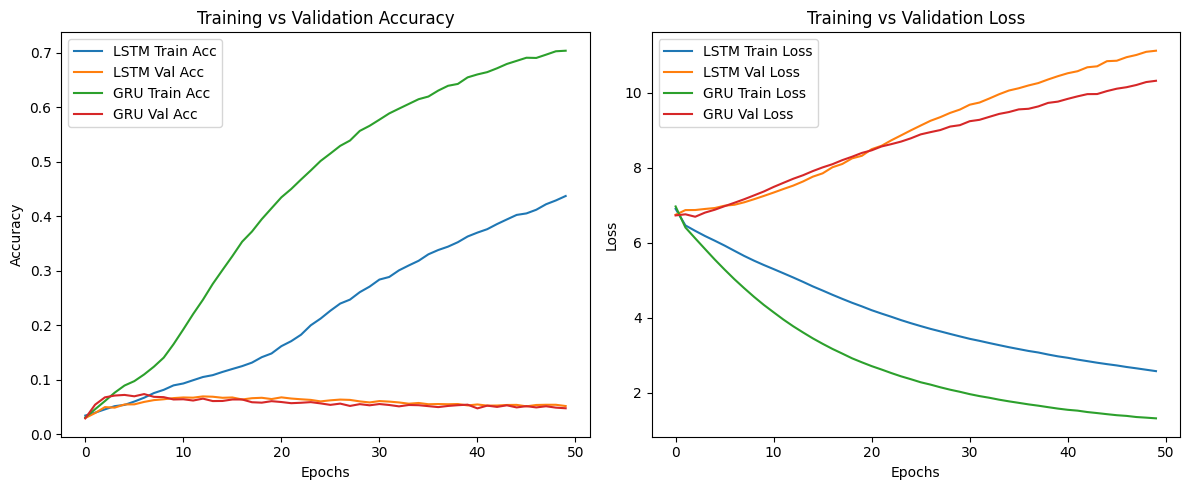

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(history_lstm['accuracy'], label='LSTM Train Acc')
plt.plot(history_lstm['val_accuracy'], label='LSTM Val Acc')
plt.plot(history.history['accuracy'], label='GRU Train Acc')
plt.plot(history.history['val_accuracy'], label='GRU Val Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history_lstm['loss'], label='LSTM Train Loss')
plt.plot(history_lstm['val_loss'], label='LSTM Val Loss')
plt.plot(history.history['loss'], label='GRU Train Loss')
plt.plot(history.history['val_loss'], label='GRU Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
lstm_acc = history_lstm['val_accuracy']
gru_acc = history.history['val_accuracy']
lstm_loss = history_lstm['val_loss']
gru_loss = history.history['val_loss']

# Find best epochs
best_epoch_lstm_acc = np.argmax(lstm_acc)
best_val_acc_lstm = lstm_acc[best_epoch_lstm_acc]

best_epoch_gru_acc = np.argmax(gru_acc)
best_val_acc_gru = gru_acc[best_epoch_gru_acc]

best_epoch_lstm_loss = np.argmin(lstm_loss)
best_val_loss_lstm = lstm_loss[best_epoch_lstm_loss]

best_epoch_gru_loss = np.argmin(gru_loss)
best_val_loss_gru = gru_loss[best_epoch_gru_loss]

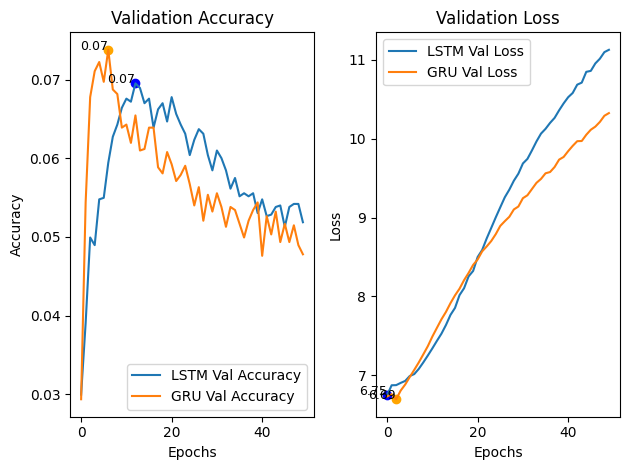

In [ ]:
# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(lstm_acc, label='LSTM Val Accuracy')
plt.plot(gru_acc, label='GRU Val Accuracy')
plt.scatter(best_epoch_lstm_acc, best_val_acc_lstm, color='blue')
plt.text(best_epoch_lstm_acc, best_val_acc_lstm, f"{best_val_acc_lstm:.2f}", fontsize=9, ha='right')
plt.scatter(best_epoch_gru_acc, best_val_acc_gru, color='orange')
plt.text(best_epoch_gru_acc, best_val_acc_gru, f"{best_val_acc_gru:.2f}", fontsize=9, ha='right')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(lstm_loss, label='LSTM Val Loss')
plt.plot(gru_loss, label='GRU Val Loss')
plt.scatter(best_epoch_lstm_loss, best_val_loss_lstm, color='blue')
plt.text(best_epoch_lstm_loss, best_val_loss_lstm, f"{best_val_loss_lstm:.2f}", fontsize=9, ha='right')
plt.scatter(best_epoch_gru_loss, best_val_loss_gru, color='orange')
plt.text(best_epoch_gru_loss, best_val_loss_gru, f"{best_val_loss_gru:.2f}", fontsize=9, ha='right')
plt.title("Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()
